In [1]:
# ============================================================
# Project 2: Clustering of Text Documents (tweets)
#
# Purpose:
# This file completes the full workflow for Project 2 using
# cnnhealth.txt as input. The goal is to take raw tweet data,
# convert the tweets into bag-of-words feature vectors,
# define and compute two distance (or similarity) measures,
# run four clustering methods, evaluate the clustering results,
# generate visualizations, and identify the meaning of one
# prominent cluster using the top ten most common words.
#
# ------------------------------------------------------------
# Input:
# - cnnhealth.txt
#   * This file contains 3 columns separated by "|"
#   * ONLY the LAST column should be used for analysis
#   * Each row corresponds to one tweet
#
# ------------------------------------------------------------
# Output:
# 1. Feature matrix output file (.txt)
#    - Bag-of-words representation of the tweets
#    - Each row is a tweet
#    - Each column is a word feature
#
# 2. Summary statistics for the feature matrix
#    - Number of tweets
#    - Number of features / vocabulary size
#    - Sparsity or density information
#    - Any other summary values used in the report
#
# 3. Two distance (or similarity) matrix files
#    - Distance / similarity measure #1 output to a file
#    - Distance / similarity measure #2 output to a file
#
# 4. Histograms of the two distance distributions
#    - Used in the report to explain the rationale for selecting
#      the two distance definitions
#
# 5. Clustering results from 4 different clustering methods
#    - Number of clusters for each method
#    - Cluster membership / labels
#    - Cluster size distribution
#
# 6. Evaluation results for the report
#    - Cohesion measure(s), such as SSE
#    - Separation measure(s), such as BSS
#    - Silhouette score
#    - Entropy and purity comparing two clustering results
#
# 7. Visualization results for the four clustering methods
#    - One of the required visualization methods:
#         * heatmap of distance matrix reordered by cluster
#         * PCA
#         * t-SNE
#    - Used to compare and discuss the four clustering methods
#
# 8. Top words for one prominent cluster
#    - Top ten most commonly used words in the selected cluster
#    - Used to interpret the meaning of the cluster
#
# ------------------------------------------------------------
# Methods / Steps:
#
# Step 1: Parse and prepare the data
# - Read cnnhealth.txt
# - Split each line using the "|" delimiter
# - Extract ONLY the last column from each line
# - Store the tweet text for analysis
# - Clean / preprocess text as needed
#
# Step 2: Construct feature vectors using Bag-of-Words
# - Convert the raw tweet text into a bag-of-words matrix
# - Each row represents one tweet
# - Each column represents a word feature
# - Word values represent word frequency
# - Save the feature matrix to a .txt file
# - Compute summary statistics for the matrix
#
# Step 3: Define and compute two distance (or similarity) measures
# - Select at least two measures appropriate for text data
# - Compute pairwise distances / similarities between tweets
# - Output each result to a separate file
# - Plot histograms of the distance distributions
# - Use these histograms in the report and explain why these
#   two measures were selected
#
# Step 4: Run four clustering methods
# - Perform experiments with 4 different clustering algorithms
# - If a method requires the number of clusters as a parameter,
#   do NOT choose it arbitrarily
# - Show how the number of clusters is determined
# - For methods with other parameters (for example DBSCAN),
#   explain how those parameters are chosen
# - Save or store the cluster labels for each method
#
# Step 5: Summarize clustering results
# - For each clustering method, report:
#     * number of clusters
#     * cluster size distribution
# - Compare methods using:
#     * cohesion (for example SSE)
#     * separation (for example BSS)
#     * silhouette score
#
# Step 6: Compare two clustering results using external-style measures
# - Select two of the clustering results
# - Compute entropy
# - Compute purity
# - Use these values to discuss the consistency between the
#   two selected clustering results
#
# Step 7: Visualize the clustering results
# - Generate visualizations for all four clustering methods
# - Use one of the required approaches:
#     * heatmap of reordered distance matrix
#     * PCA
#     * t-SNE
# - Compare and discuss the methods based on the visual results
#
# Step 8: Interpret one prominent cluster
# - Select one prominent cluster from one of the four results
# - Find the top ten most commonly used words in that cluster
# - Use the words to infer the meaning / topic of the cluster
#
# ------------------------------------------------------------
# Report Requirements Supported by This Code:
# - Summary results of the feature matrix
# - Rationale for distance definitions and histograms
# - Justification for clustering parameters
# - Summary results from all four clustering methods
# - Cohesion, separation, and silhouette comparisons
# - Entropy and purity for two selected results
# - Visualization of all four clustering results
# - Top ten words and interpretation of one cluster
#
# ------------------------------------------------------------
# Notes:
# - This code should directly take cnnhealth.txt as input
# - Only the last column of the file is used in the analysis
# - Output files such as the feature matrix and distance matrices
#   are generated by the code but are not meant to be submitted
# - The code file should include comments/documentation throughout
#   to explain each major step
# ============================================================

### Step 1: Parse and prepare the data

In [2]:
# ============================================================
# Step 1: Parse and Prepare the Data
# - Read cnnhealth.txt
# - Split each line using the "|" delimiter
# - Extract ONLY the last column
# - Store tweet text
# ============================================================

file_path = "cnnhealth.txt"

tweets = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split("|")
        if len(parts) >= 3:
            tweet = parts[-1]   # last column
            tweets.append(tweet)

# Clean basic whitespace
tweets = [t.strip() for t in tweets if t.strip()]

# -------------------------
# Clean output summaries
# -------------------------

print("Data Parsing Complete")
print("---------------------")
print(f"Total tweets loaded: {len(tweets)}")

print("\nSample tweets:")
for i in range(3):
    print(f"{i+1}. {tweets[i]}")

Data Parsing Complete
---------------------
Total tweets loaded: 4061

Sample tweets:
1. An abundance of online info can turn us into e-hypochondriacs. Or, worse, lead us to neglect getting the care we need http://cnn.it/1L1t1Fv
2. A plant-based diet that incorporates fish may be the key to preventing colorectal cancers: http://cnn.it/1xdpsjT http://pbs.twimg.com/media/CAARHEGWEAAJGz6.jpg
3. It doesn't take much to damage your hearing at a sports bar or nightclub. That's why a billion people are at risk. http://cnn.it/1BOphBk


### Step 2: Construct feature vectors using Bag-of-Words

In [3]:
# ============================================================
# Step 2: Construct Feature Vectors using Bag-of-Words
# - Convert tweets into a bag-of-words matrix
# - Each row = tweet
# - Each column = word feature
# - Values = word frequency
# - Save matrix to matrix.txt
# - Compute summary statistics
# ============================================================

from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

print("Step 2: Building Bag-of-Words matrix")

# Create bag-of-words matrix, and remove stopwords
vectorizer = CountVectorizer(stop_words="english")
X = vectorizer.fit_transform(tweets)
matrix = X.toarray()

print(f"Matrix created with shape {matrix.shape}")

# Save matrix
np.savetxt("matrix.txt", matrix, fmt="%d")
print("Saved matrix to matrix.txt")

# Compute summary statistics
num_documents = matrix.shape[0]
num_unique_terms = matrix.shape[1]
term_tokens = matrix.sum()
avg_terms_per_doc = term_tokens / num_documents

summary = f"""#Documents: {num_documents}
#Term Tokens: {term_tokens}
#Unique Terms: {num_unique_terms}
Avg Terms Per Document: {avg_terms_per_doc:.1f}
"""

# Save summary
with open("matrix_summary_statistics.txt", "w") as f:
    f.write(summary)

print("Summary statistics saved to matrix_summary_statistics.txt")
print(summary)

Step 2: Building Bag-of-Words matrix
Matrix created with shape (4061, 11016)
Saved matrix to matrix.txt
Summary statistics saved to matrix_summary_statistics.txt
#Documents: 4061
#Term Tokens: 51046
#Unique Terms: 11016
Avg Terms Per Document: 12.6



### Step 3: Define and compute two distance (or similarity) measures

Computing cosine similarity...
Saved cosine similarity matrix


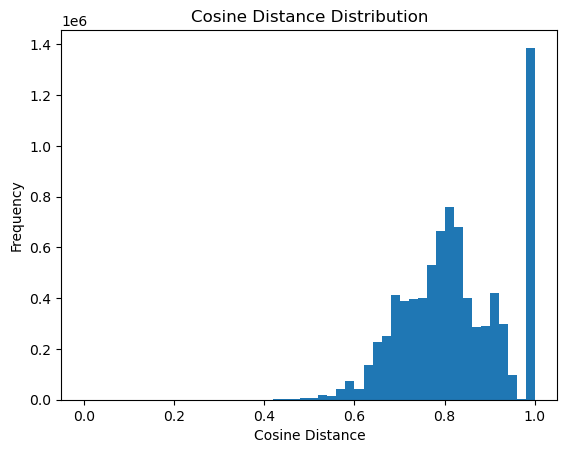

Computing Jaccard distance...


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Saved Jaccard distance matrix


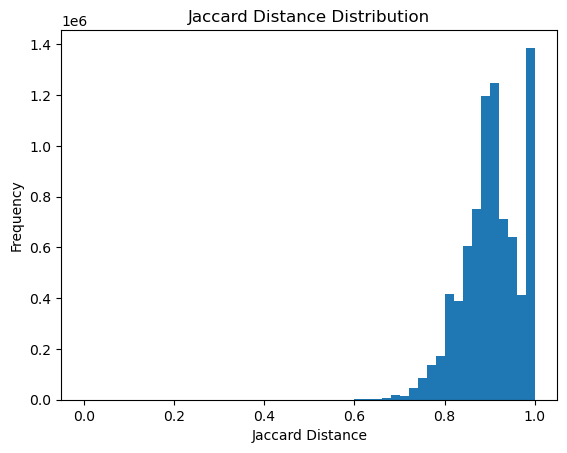

In [5]:
# Step 3: Define and compute two distance (or similarity) measures
# - Select at least two measures appropriate for text data
# - Compute pairwise distances / similarities between tweets
# - Output each result to a separate file
# - Plot histograms of the distance distributions
# - Use these histograms in the report and explain why these
#   two measures were selected

# cosine similairity distance measure
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

print("Computing cosine similarity...")

# Load feature matrix
X = np.loadtxt("matrix.txt")

# Compute cosine similarity matrix
cos_sim = cosine_similarity(X)

# Save similarity matrix
np.savetxt("cosine_similarity_matrix.txt", cos_sim, fmt="%.4f")
print("Saved cosine similarity matrix")

# Convert to cosine distance
cos_dist = 1 - cos_sim

# Use only upper triangle (avoid duplicates & diagonal)
distances = cos_dist[np.triu_indices_from(cos_dist, k=1)]

# Plot histogram
plt.hist(distances, bins=50)
plt.title("Cosine Distance Distribution")
plt.xlabel("Cosine Distance")
plt.ylabel("Frequency")
plt.show()

# Jaccard distance measure
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

print("Computing Jaccard distance...")

# Load feature matrix
X = np.loadtxt("matrix.txt")

# Convert to binary (word present or not)
X_binary = (X > 0).astype(int)

# Compute Jaccard distance matrix
jaccard_dist = pairwise_distances(X_binary, metric="jaccard")

# Save distance matrix
np.savetxt("jaccard_distance_matrix.txt", jaccard_dist, fmt="%.4f")
print("Saved Jaccard distance matrix")

# Use only upper triangle (avoid duplicates & diagonal)
distances = jaccard_dist[np.triu_indices_from(jaccard_dist, k=1)]

# Plot histogram
plt.hist(distances, bins=50)
plt.title("Jaccard Distance Distribution")
plt.xlabel("Jaccard Distance")
plt.ylabel("Frequency")
plt.show()

### Step 4: Run four clustering methods

Generating k-distance plot...


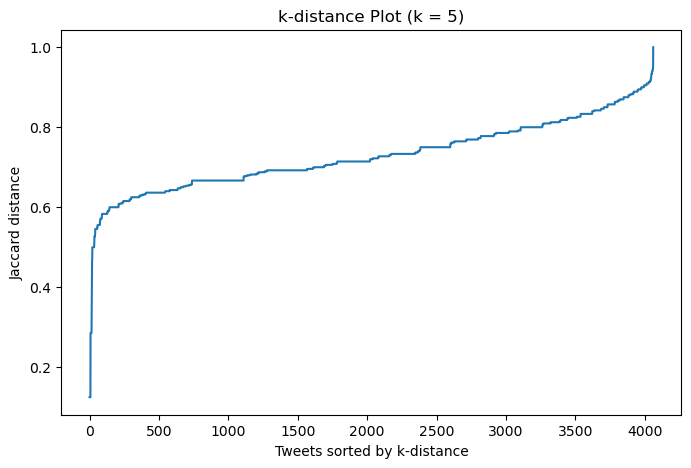


Evaluating candidate eps values...

eps = 0.78
  clusters   = 4
  noise      = 645
  silhouette = 0.0367
-----
eps = 0.75
  clusters   = 8
  noise      = 917
  silhouette = 0.0474
-----
eps = 0.72
  clusters   = 10
  noise      = 1426
  silhouette = 0.0255
-----

Running final DBSCAN model...
Saved labels to dbscan_jaccard_labels.txt

Final parameters:
  eps = 0.75
  min_samples = 5

Number of clusters: 8
Number of noise points: 917

Cluster size distribution:
  cluster_0: 3079
  cluster_1: 14
  cluster_2: 7
  cluster_3: 6
  cluster_4: 20
  cluster_5: 5
  cluster_6: 8
  cluster_7: 5

Silhouette score (excluding noise): 0.0474


In [10]:
# Step 4: Run four clustering methods
# - Perform experiments with 4 different clustering algorithms
# - If a method requires the number of clusters as a parameter,
#   do NOT choose it arbitrarily
# - Show how the number of clusters is determined
# - For methods with other parameters (for example DBSCAN),
#   explain how those parameters are chosen
# - Save or store the cluster labels for each method


# ============================================================
# Step 4a: DBSCAN using Jaccard distance
# - Use a k-distance plot to estimate eps
# - Compare candidate eps values
# - Run final DBSCAN model
# - Save cluster labels
# - Print number of clusters, cluster size distribution,
#   and silhouette score
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# ------------------------------------------------------------
# Load precomputed Jaccard distance matrix
# ------------------------------------------------------------
D = np.loadtxt("jaccard_distance_matrix.txt")

# ------------------------------------------------------------
# 1. Generate k-distance plot to estimate eps
# ------------------------------------------------------------
print("Generating k-distance plot...")

min_samples = 5
k = min_samples

# Distance to the k-th nearest neighbor for each tweet
k_distances = []
for row in D:
    sorted_distances = np.sort(row)
    k_distances.append(sorted_distances[k])   # index k skips self-distance at index 0

k_distances = np.sort(np.array(k_distances))

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title(f"k-distance Plot (k = {k})")
plt.xlabel("Tweets sorted by k-distance")
plt.ylabel("Jaccard distance")
plt.show()

# ------------------------------------------------------------
# 2. Evaluate candidate eps values
# ------------------------------------------------------------
print("\nEvaluating candidate eps values...\n")

candidate_eps = [0.78, 0.75, 0.72]

for eps in candidate_eps:
    dbscan = DBSCAN(metric="precomputed", eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(D)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    # Silhouette is computed only on non-noise points
    mask = labels != -1
    labels_no_noise = labels[mask]

    if len(set(labels_no_noise)) >= 2:
        D_no_noise = D[np.ix_(mask, mask)]
        silhouette = silhouette_score(D_no_noise, labels_no_noise, metric="precomputed")
        silhouette_str = f"{silhouette:.4f}"
    else:
        silhouette_str = "not defined"

    print(f"eps = {eps}")
    print(f"  clusters   = {n_clusters}")
    print(f"  noise      = {n_noise}")
    print(f"  silhouette = {silhouette_str}")
    print("-----")

# ------------------------------------------------------------
# 3. Run final DBSCAN model
# Final choice based on k-distance plot + candidate comparison
# ------------------------------------------------------------
print("\nRunning final DBSCAN model...")

eps = 0.75
dbscan = DBSCAN(metric="precomputed", eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(D)

# Save cluster labels
np.savetxt("dbscan_jaccard_labels.txt", labels, fmt="%d")
print("Saved labels to dbscan_jaccard_labels.txt")

# ------------------------------------------------------------
# 4. Print clustering summary
# ------------------------------------------------------------
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

cluster_sizes = Counter(labels)
cluster_size_distribution = {
    f"cluster_{label}": size
    for label, size in sorted(cluster_sizes.items())
    if label != -1
}

print(f"\nFinal parameters:")
print(f"  eps = {eps}")
print(f"  min_samples = {min_samples}")

print(f"\nNumber of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")

print("\nCluster size distribution:")
for cluster, size in cluster_size_distribution.items():
    print(f"  {cluster}: {size}")

# ------------------------------------------------------------
# 5. Compute silhouette score for final model
# ------------------------------------------------------------
mask = labels != -1
labels_no_noise = labels[mask]

if len(set(labels_no_noise)) >= 2:
    D_no_noise = D[np.ix_(mask, mask)]
    silhouette = silhouette_score(D_no_noise, labels_no_noise, metric="precomputed")
    print(f"\nSilhouette score (excluding noise): {silhouette:.4f}")
else:
    print("\nSilhouette score: not defined (fewer than 2 non-noise clusters)")